In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, BatchNormalization  
from tensorflow.keras.utils import to_categorical  
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.regularizers import l2 
import seaborn as sns

In [2]:
# Cell 2: Load Data
FEATURES_PATH = r"F:\RealTime_Music_Genre_Classification\features\data.npy"
LABELS_PATH = r"F:\RealTime_Music_Genre_Classification\features\labels.npy"

X = np.load(FEATURES_PATH)
y = np.load(LABELS_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999, 40)
y shape: (999,)


In [3]:
# Cell 3: Data Augmentation Function
def augment_data(X, y, augmentation_factor=2):
    """
    Augment the data by adding noise and time shifts
    """
    X_augmented = []
    y_augmented = []
    
    for i in range(len(X)):
        # Original sample
        X_augmented.append(X[i])
        y_augmented.append(y[i])
        
        # Add augmented samples
        for _ in range(augmentation_factor):
            # Add random noise
            noise = np.random.normal(0, 0.005, X[i].shape)
            augmented = X[i] + noise
            
            X_augmented.append(augmented)
            y_augmented.append(y[i])
    
    return np.array(X_augmented), np.array(y_augmented)

# Augment training data
print("Augmenting data...")
X_augmented, y_augmented = augment_data(X, y, augmentation_factor=1)
print("Augmented X shape:", X_augmented.shape)
print("Augmented y shape:", y_augmented.shape)

Augmenting data...
Augmented X shape: (1998, 40)
Augmented y shape: (1998,)


In [4]:
# Cell 4: Train-Test Split and Preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented, test_size=0.2, random_state=42, stratify=y_augmented
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("CNN input shape:", X_train.shape)

Training samples: (1598, 40)
Testing samples: (400, 40)
CNN input shape: (1598, 40, 1)


In [5]:
# Cell 5: One-Hot Encoding
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)

Number of classes: 10


In [6]:
# Cell 6: Improved CNN Model
def create_improved_model(input_shape, num_classes):
    model = Sequential([
        # First Conv Block
        Conv1D(128, kernel_size=3, activation='relu', input_shape=input_shape, 
               kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Second Conv Block
        Conv1D(256, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Conv1D(256, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        
        # Third Conv Block
        Conv1D(512, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        
        # Dense Layers
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

model = create_improved_model(input_shape=(40, 1), num_classes=num_classes)

# Compile with custom learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 38, 128)           512       
                                                                 
 batch_normalization (Batch  (None, 38, 128)           512       
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 36, 128)           49280     
                                                                 
 batch_normalization_1 (Bat  (None, 36, 128)           512       
 chNormalization)                                                
                                                                 
 max_pooling1d (MaxPooling1  (None, 18, 128)           0         
 D)                                                              
                                                        

In [7]:
# Cell 7: Callbacks and Training
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Learning Rate Reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    r'F:\RealTime_Music_Genre_Classification\model\best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
50/50 [==============================] - ETA: 0s - loss: 4.8923 - accuracy: 0.2040
Epoch 1: val_accuracy improved from -inf to 0.11500, saving model to F:\RealTime_Music_Genre_Classification\model\best_model.h5
50/50 [==============================] - 5s 39ms/step - loss: 4.8923 - accuracy: 0.2040 - val_loss: 4.3598 - val_accuracy: 0.1150 - lr: 0.0010
Epoch 2/100
49/50 [============================>.] - ETA: 0s - loss: 4.3597 - accuracy: 0.2940
Epoch 2: val_accuracy did not improve from 0.11500
50/50 [==============================] - 2s 30ms/step - loss: 4.3624 - accuracy: 0.2941 - val_loss: 4.4366 - val_accuracy: 0.1025 - lr: 0.0010
Epoch 3/100
49/50 [============================>.] - ETA: 0s - loss: 4.1859 - accuracy: 0.3240
Epoch 3: val_accuracy did not improve from 0.11500
50/50 [==============================] - 2s 30ms/step - loss: 4.1888 - accuracy: 0.3242 - val_loss: 4.4128 - val_accuracy: 0.0975 - lr: 0.0010
Epoch 4/100
49/50 [============================>.] - ETA

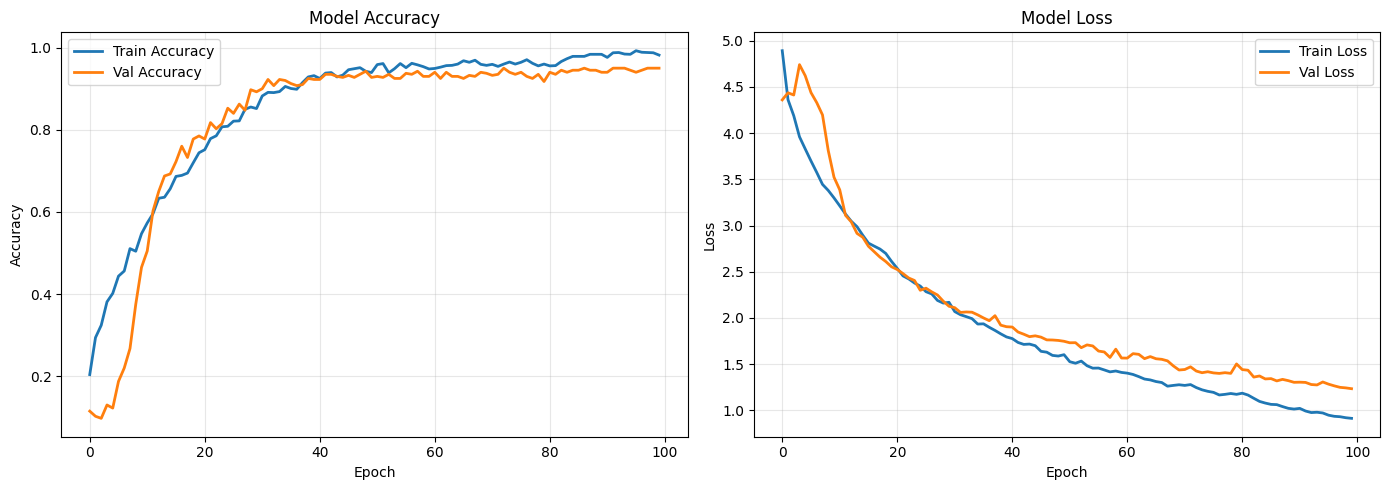


Best Validation Accuracy: 0.9500 at Epoch 73


In [8]:
# Cell 8: Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
plt.legend()
plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.legend()
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best accuracy
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch}")

13/13 [==============================] - 0s 5ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        40
           1       0.95      0.95      0.95        40
           2       0.79      0.95      0.86        40
           3       1.00      0.95      0.97        40
           4       1.00      1.00      1.00        40
           5       1.00      0.95      0.97        40
           6       0.95      1.00      0.98        40
           7       1.00      0.95      0.97        40
           8       0.95      1.00      0.98        40
           9       0.94      0.85      0.89        40

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



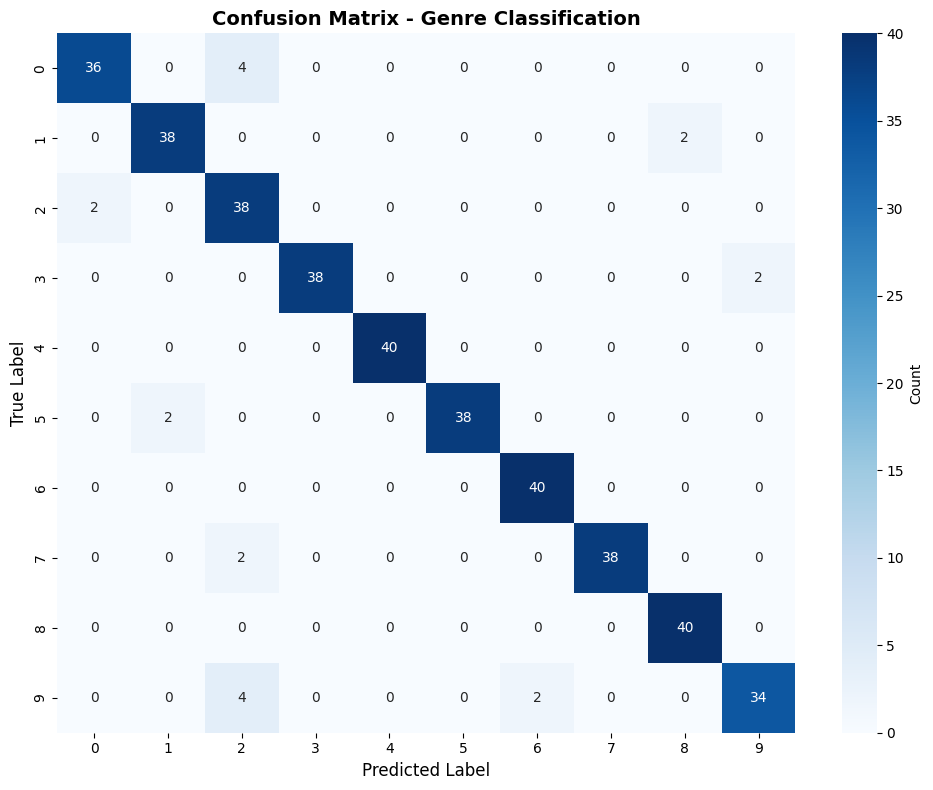


Overall Test Accuracy: 0.9500


In [9]:
# Cell 9: Evaluation and Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Genre Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and print overall accuracy
overall_accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}")

In [10]:
# Cell 10: Save Model and Scaler
MODEL_PATH = r"F:\RealTime_Music_Genre_Classification\model\cnn_genre_model.h5"
SCALER_PATH = r"F:\RealTime_Music_Genre_Classification\model\scaler.npy"

model.save(MODEL_PATH)
np.save(SCALER_PATH, scaler.mean_)
np.save(r"F:\RealTime_Music_Genre_Classification\model\scaler_scale.npy", scaler.scale_)

print("Model and scaler saved successfully!")
print(f"Final Test Accuracy: {overall_accuracy:.4f}")

Model and scaler saved successfully!
Final Test Accuracy: 0.9500
